In [16]:
import pandas as pd
valid_df = pd.read_csv("/kaggle/input/datasets/milanarjel/final-data-major/valid_data.csv")
roberta_valid  = pd.read_csv("/kaggle/input/datasets/milanarjel/final-last-ensemble-data/valid_predictions_xlm-roberta-base.csv")
minilm_valid = pd.read_csv("/kaggle/input/datasets/milanarjel/final-last-ensemble-data/valid_predictions_Multilingual-MiniLM-L12-H384.csv")
nepberta_valid = pd.read_csv("/kaggle/input/datasets/milanarjel/final-last-ensemble-data/valid_predictions_nepberta.csv")
svc_valid = pd.read_csv("/kaggle/input/datasets/milanarjel/final-last-ensemble-data/valid_predictions_SVC.csv")
xgboost_valid = pd.read_csv("/kaggle/input/datasets/milanarjel/final-last-ensemble-data/valid_predictions_XGBoost.csv")
lr_valid = pd.read_csv("/kaggle/input/datasets/milanarjel/final-last-ensemble-data/valid_predictions_Logistic Regression.csv")
valid_data = pd.concat([svc_valid,roberta_valid,nepberta_valid ,minilm_valid],axis=1)
valid_data['label'] = valid_df['label']


In [17]:
test_df = pd.read_csv("/kaggle/input/datasets/milanarjel/final-data-major/test_data.csv")
roberta_test = pd.read_csv("/kaggle/input/datasets/milanarjel/final-last-ensemble-data/test_predictions_xlm-roberta-base.csv")
minilm_test = pd.read_csv("/kaggle/input/datasets/milanarjel/final-last-ensemble-data/test_predictions_Multilingual-MiniLM-L12-H384.csv")
nepberta_test = pd.read_csv("/kaggle/input/datasets/milanarjel/final-last-ensemble-data/test_predictions_nepberta.csv")
svc_test = pd.read_csv("/kaggle/input/datasets/milanarjel/final-last-ensemble-data/test_predictions_SVC.csv")
xgboost_test = pd.read_csv("/kaggle/input/datasets/milanarjel/final-last-ensemble-data/test_predictions_XGBoost.csv")
lr_test = pd.read_csv("/kaggle/input/datasets/milanarjel/final-last-ensemble-data/test_predictions_Logistic Regression.csv")
test_data = pd.concat([svc_test,roberta_test,nepberta_test,minilm_test],axis=1)
test_data['label'] = test_df['label']

In [18]:
# import joblib
# X, y = valid_data.drop('label',axis=1), valid_data.label
# X_test , y_test = test_data.drop('label',axis = 1) , test_data.label
# base_dt = DecisionTreeClassifier(random_state=42)
# bagging_dt = BaggingClassifier(
#             estimator=base_dt,
#             n_estimators=100,
#             max_samples=0.8,  # Use 80% of samples
#             max_features=0.8,  # Use 80% of features
#             bootstrap=True,    # Sample with replacement
#             bootstrap_features=True,
#             random_state=42
#         )


        
# bagging_dt.fit(X,y)
# joblib.dump(bagging_dt, "bagging_dt_model.pkl")
# y_pred = bagging_dt.predict(X_test)
        
# metrics = evaluate_model(y_test, y_pred, "Bagging with Decision Tree")
# plot_confusion_matrix(y_test, y_pred, model_name="Bagging (DT)")
# print(metrics)
        

In [19]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import matthews_corrcoef, roc_auc_score

def evaluate_model(y_true, y_pred,y_prob, model_name="Model"):
    """Calculate various metrics for model evaluation"""
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)

    print(f"\n{model_name} Performance Metrics:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    # mcc = matthews_corrcoef(y_true, y_pred)
    # print(f"MCC : {mcc}")
    # auc = roc_auc_score(y_true, y_prob[:,1])
    # print(f"AUC : {auc}")
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_macro': f1
    }

def plot_confusion_matrix(y_true, y_pred, labels=None, model_name="Model"):
    """Plot confusion matrix using seaborn"""
    cm = confusion_matrix(y_true, y_pred)  # Ensure conversion to array
    
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Human Labeled', 'AI Labeled'],
                yticklabels=['Human Labeled', 'AI Labeled'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

# Create the individual base models
base_models = [
    ('lr', LogisticRegression()),
    ('rf', RandomForestClassifier(random_state=42)),
    ('xgb', XGBClassifier(random_state=42)),
    ('lgb', LGBMClassifier(random_state=42, verbose=-1)),
    ('catboost', CatBoostClassifier(random_state=42, verbose=0)),
    ('nb', GaussianNB()),
    ('svc', SVC()),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('mlp', MLPClassifier(random_state=42))
]

class EnsembleExperiments:
    def __init__(self, X, y,X_test,y_test):
        self.X_train = X
        self.y_train = y
        self.X_test = X_test
        self.y_test = y_test
        # self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
        #     X, y, test_size=0.2, random_state=42)
        
        # For models that benefit from scaling
        self.scaler = StandardScaler()
        self.X_train_scaled = self.scaler.fit_transform(self.X_train)
        self.X_test_scaled = self.scaler.transform(self.X_test)
        
        # Store results for comparison
        self.results = {}
    
    def run_all_experiments(self):
        """Run all ensemble experiments and compare results"""
        # self.train_base_models()
        # self.train_voting_classifier()
        # self.train_weighted_voting_classifier()
        self.train_soft_voting_classifier()
        self.train_stacking_classifier()
        self.train_advanced_stacking()
        self.train_bagging_classifier()
        self.train_boosting_models()
        # self.train_custom_ensemble()
        self.compare_results()
    
    # def train_base_models(self):
    #     """Train and evaluate individual base models"""
    #     for name, model in base_models:
    #         print(f"Training {name}...")
    #         try:
    #             # Use scaled data for models that benefit from it
    #             if name in ['lr', 'svc', 'knn', 'mlp']:
    #                 model.fit(self.X_train_scaled, self.y_train)
    #                 y_pred = model.predict(self.X_test_scaled)
    #             else:
    #                 model.fit(self.X_train, self.y_train)
    #                 y_pred = model.predict(self.X_test)
                
    #             metrics = evaluate_model(self.y_test, y_pred, name)
    #             self.results[name] = metrics
    #         except Exception as e:
    #             print(f"Error training {name}: {str(e)}")
    
    def train_voting_classifier(self):
        """Train and evaluate hard voting classifier"""
        # Use only models that don't require probability estimates for hard voting
        voting_models = [model for model in base_models if model[0] not in ['svc']]
        
        voting_clf = VotingClassifier(estimators=voting_models, voting='hard')
        voting_clf.fit(self.X_train, self.y_train)
        y_pred = voting_clf.predict(self.X_test)
        y_prob = voting_clf.predict_proba(self.X_test)
        
        metrics = evaluate_model(self.y_test, y_pred,y_prob, "Hard Voting Classifier")
        plot_confusion_matrix(self.y_test, y_pred, model_name="Hard Voting")
        self.results['hard_voting'] = metrics
    
    def train_weighted_voting_classifier(self):
        """Train and evaluate weighted voting classifier"""
        # Define weights based on individual model performance
        # Higher weights for better performing models
        weighted_models = [model for model in base_models if model[0] not in ['svc']]
        
        weights = [1,1,1,1,1,1,1,1]  # Example weights matching the filtered models
        
        weighted_voting = VotingClassifier(
            estimators=weighted_models,
            voting='hard', 
            #weights=weights
        )
        
        weighted_voting.fit(self.X_train, self.y_train)
        y_pred = weighted_voting.predict(self.X_test)
        y_prob = weighted_voting.predict_proba(self.X_test)
        
        metrics = evaluate_model(self.y_test, y_pred,y_prob, "Weighted Voting Classifier")
        plot_confusion_matrix(self.y_test, y_pred, model_name="Weighted Voting")
        self.results['weighted_voting'] = metrics
    
    def train_soft_voting_classifier(self):
        """Train and evaluate soft voting classifier"""
        # Use only models that can predict probabilities
        soft_models = [
            ('lr', LogisticRegression(max_iter=1000)),
            ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
            ('xgb', XGBClassifier(n_estimators=100, random_state=42)),
            ('lgb', LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)),
            ('nb', GaussianNB()),
            ('svc', SVC(probability=True)),  # Enable probability
            ('knn', KNeighborsClassifier(n_neighbors=5)),
            ('dt', DecisionTreeClassifier(random_state=42))
        ]
        
        soft_voting = VotingClassifier(
            estimators=soft_models,
            voting='soft'
        )
        
        soft_voting.fit(self.X_train, self.y_train)
        y_pred = soft_voting.predict(self.X_test)
        y_prob = soft_voting.predict_proba(self.X_test)
        
        metrics = evaluate_model(self.y_test, y_pred,y_prob, "Soft Voting Classifier")
        plot_confusion_matrix(self.y_test, y_pred, model_name="Soft Voting")
        self.results['soft_voting'] = metrics
    
    def train_stacking_classifier(self):
        """Train and evaluate basic stacking classifier"""
        # First level estimators
        estimators = [
            ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
            ('xgb', XGBClassifier(n_estimators=100, random_state=42)),
            ('lgb', LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)),
            ('dt', DecisionTreeClassifier(random_state=42))
        ]
        
        # Final estimator
        final_estimator = LogisticRegression(max_iter=1000)
        
        # Create stacking classifier
        stacking_clf = StackingClassifier(
            estimators=estimators,
            final_estimator=final_estimator,
            cv=5  # 5-fold cross-validation
        )
        
        stacking_clf.fit(self.X_train, self.y_train)
        y_pred = stacking_clf.predict(self.X_test)
        y_prob = stacking_clf.predict_proba(self.X_test)
        
        metrics = evaluate_model(self.y_test, y_pred,y_prob, "Basic Stacking Classifier")
        plot_confusion_matrix(self.y_test, y_pred, model_name="Basic Stacking")
        self.results['basic_stacking'] = metrics
    
    def train_advanced_stacking(self):
        """Train and evaluate advanced stacking with meta-features"""
        # First level estimators
        estimators = [
            ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
            ('xgb', XGBClassifier(n_estimators=100, random_state=42)),
            ('lgb', LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)),
            ('catboost', CatBoostClassifier(n_estimators=100, random_state=42, verbose=0))
        ]
        
        # Final estimator (meta-learner)
        # Using a more complex meta-learner
        final_estimator = GradientBoostingClassifier(n_estimators=100, random_state=42)
        
        # Create advanced stacking classifier
        stacking_clf = StackingClassifier(
            estimators=estimators,
            final_estimator=final_estimator,
            cv=5,  # 5-fold cross-validation
            stack_method='predict_proba',  # Use probability predictions
            passthrough=True  # Include original features
        )
        
        stacking_clf.fit(self.X_train, self.y_train)
        y_pred = stacking_clf.predict(self.X_test)
        y_prob = stacking_clf.predict_proba(self.X_test)
        
        metrics = evaluate_model(self.y_test, y_pred,y_prob, "Advanced Stacking Classifier")
        plot_confusion_matrix(self.y_test, y_pred, model_name="Advanced Stacking")
        self.results['advanced_stacking'] = metrics
    
    def train_bagging_classifier(self):
        """Train and evaluate various bagging classifiers"""
        # 1. Basic Bagging with Decision Tree
        base_dt = DecisionTreeClassifier(random_state=42)
        bagging_dt = BaggingClassifier(
            estimator=base_dt,
            n_estimators=100,
            max_samples=0.8,  # Use 80% of samples
            max_features=0.8,  # Use 80% of features
            bootstrap=True,    # Sample with replacement
            bootstrap_features=True,
            random_state=42
        )
        
        bagging_dt.fit(self.X_train, self.y_train)
        y_pred = bagging_dt.predict(self.X_test)
        y_prob = bagging_dt.predict_proba(self.X_test)
        
        metrics = evaluate_model(self.y_test, y_pred,y_prob, "Bagging with Decision Tree")
        plot_confusion_matrix(self.y_test, y_pred, model_name="Bagging (DT)")
        self.results['bagging_dt'] = metrics
        
        # 2. Bagging with SVC
        base_svc = SVC(probability=True)
        bagging_svc = BaggingClassifier(
            estimator=base_svc,
            n_estimators=50,  # Fewer estimators due to SVC complexity
            max_samples=0.8,
            bootstrap=True,
            random_state=42
        )
        
        bagging_svc.fit(self.X_train_scaled, self.y_train)  # Using scaled data for SVC
        y_pred = bagging_svc.predict(self.X_test_scaled)
        y_prob = bagging_svc.predict_proba(self.X_test)
        
        metrics = evaluate_model(self.y_test, y_pred,y_prob, "Bagging with SVC")
        plot_confusion_matrix(self.y_test, y_pred, model_name="Bagging (SVC)")
        self.results['bagging_svc'] = metrics
    
    def train_boosting_models(self):
        """Train and evaluate boosting-based models"""
        # 1. AdaBoost with Decision Tree
        ada_boost = AdaBoostClassifier(
            estimator=DecisionTreeClassifier(),
            random_state=42
        )
        
        ada_boost.fit(self.X_train, self.y_train)
        y_pred = ada_boost.predict(self.X_test)
        y_prob = ada_boost.predict_proba(self.X_test)
        
        metrics = evaluate_model(self.y_test, y_pred,y_prob, "AdaBoost Classifier")
        plot_confusion_matrix(self.y_test, y_pred, model_name="AdaBoost")
        self.results['adaboost'] = metrics
        
        # 2. Gradient Boosting
        gb_clf = GradientBoostingClassifier(
            random_state=42
        )
        
        gb_clf.fit(self.X_train, self.y_train)
        y_pred = gb_clf.predict(self.X_test)
        y_prob = gb_clf.predict_proba(self.X_test)
        
        metrics = evaluate_model(self.y_test, y_pred,y_prob, "Gradient Boosting Classifier")
        plot_confusion_matrix(self.y_test, y_pred, model_name="Gradient Boosting")
        self.results['gradient_boosting'] = metrics
    
    def train_custom_ensemble(self):
        """Implement a custom ensemble that uses both hard and soft voting concepts"""
        # First level models
        models = [
            ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
            ('xgb', XGBClassifier(n_estimators=100, random_state=42)),
            ('lgb', LGBMClassifier(n_estimators=100, random_state=42, verbose=-1))
        ]
        
        # Train first level models and collect predictions
        first_level_preds = np.zeros((self.X_test.shape[0], len(models)))
        
        for i, (name, model) in enumerate(models):
            print(f"Training {name} for custom ensemble...")
            model.fit(self.X_train, self.y_train)
            y_pred = model.predict(self.X_test)
            first_level_preds[:, i] = y_pred
        
        # Apply a simple weighted average rule for the final prediction
        # Get weights based on cross-validation performance
        weights = np.zeros(len(models))
        for i, (name, model) in enumerate(models):
            cv_scores = cross_val_score(model, self.X_train, self.y_train, cv=5)
            weights[i] = np.mean(cv_scores)
        
        # Normalize weights
        weights = weights / np.sum(weights)
        print(f"Model weights for custom ensemble: {weights}")
        
        # Apply weighted voting
        weighted_preds = np.zeros(self.X_test.shape[0])
        for i in range(len(models)):
            weighted_preds += weights[i] * first_level_preds[:, i]
        
        # Round to get final predictions
        final_preds = np.round(weighted_preds).astype(int)
        
        metrics = evaluate_model(self.y_test, final_preds, "Custom Ensemble Classifier")
        plot_confusion_matrix(self.y_test, final_preds, model_name="Custom Ensemble")
        self.results['custom_ensemble'] = metrics
    
    def compare_results(self):
        """Compare and visualize results from all models"""
        # Create a DataFrame from the results
        results_df = pd.DataFrame(self.results).T
        
        # Sort by accuracy
        results_df = results_df.sort_values(by='accuracy', ascending=False)
        
        # Display results
        print("\n=== Model Comparison ===")
        print(results_df)
        
        # Plot accuracy comparison
        plt.figure(figsize=(12, 6))
        results_df['accuracy'].plot(kind='bar', color='skyblue')
        plt.title('Model Accuracy Comparison')
        plt.xlabel('Model')
        plt.ylabel('Accuracy')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
        
        # Plot F1 score comparison
        plt.figure(figsize=(12, 6))
        results_df['f1_macro'].plot(kind='bar', color='lightgreen')
        plt.title('Model F1 Score Comparison')
        plt.xlabel('Model')
        plt.ylabel('F1 Score (Macro)')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
        
        # Return the best model and its performance
        best_model = results_df.index[0]
        best_performance = results_df.iloc[0]
        
        print(f"\nBest performing model: {best_model}")
        print(f"Best model performance: {best_performance}")
        
        return best_model, best_performance


Soft Voting Classifier Performance Metrics:
Accuracy: 0.9831
Precision: 0.9831
Recall: 0.9830
F1 Score: 0.9831


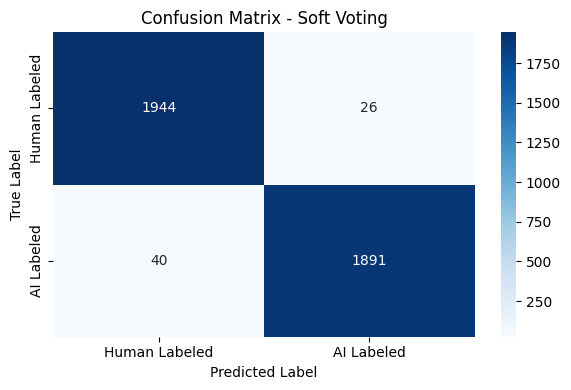


Basic Stacking Classifier Performance Metrics:
Accuracy: 0.9831
Precision: 0.9831
Recall: 0.9831
F1 Score: 0.9831


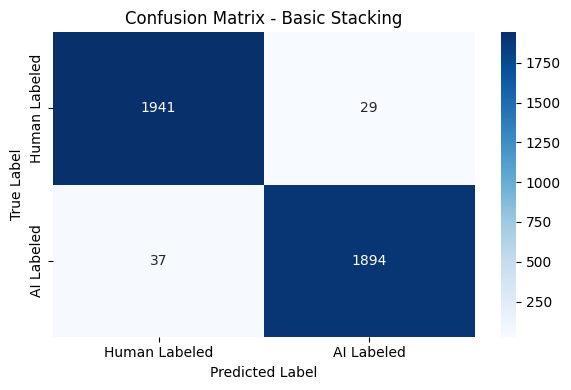


Advanced Stacking Classifier Performance Metrics:
Accuracy: 0.9854
Precision: 0.9855
Recall: 0.9853
F1 Score: 0.9854


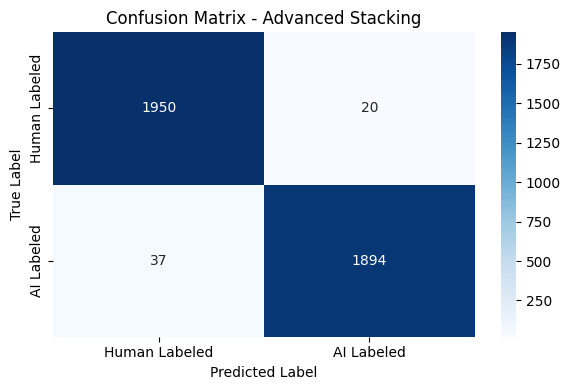


Bagging with Decision Tree Performance Metrics:
Accuracy: 0.9841
Precision: 0.9842
Recall: 0.9841
F1 Score: 0.9841


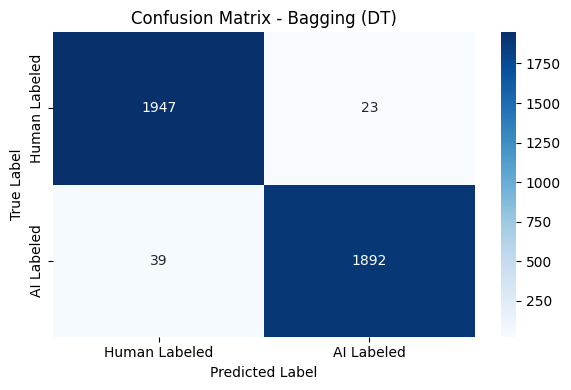

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but BaggingClassifier was fitted without feature names
  warnings.warn(



Bagging with SVC Performance Metrics:
Accuracy: 0.9810
Precision: 0.9811
Recall: 0.9810
F1 Score: 0.9810


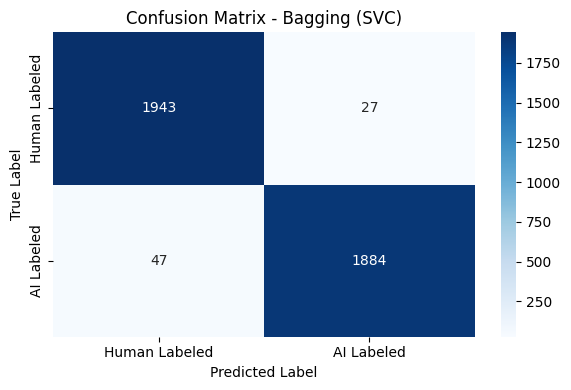


AdaBoost Classifier Performance Metrics:
Accuracy: 0.9756
Precision: 0.9756
Recall: 0.9757
F1 Score: 0.9756


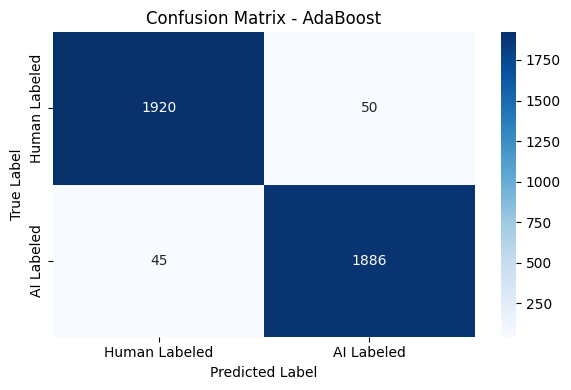


Gradient Boosting Classifier Performance Metrics:
Accuracy: 0.9833
Precision: 0.9834
Recall: 0.9833
F1 Score: 0.9833


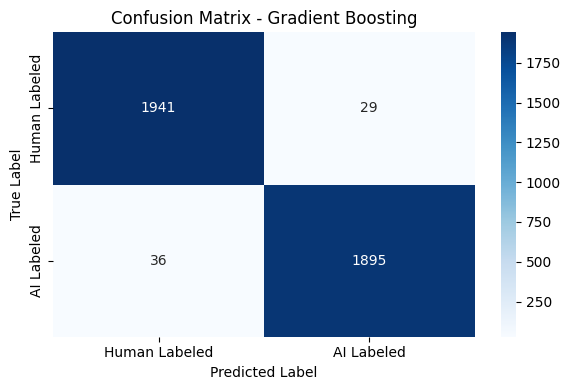


=== Model Comparison ===
                   accuracy  precision    recall  f1_macro
advanced_stacking  0.985388   0.985465  0.985343  0.985385
bagging_dt         0.984107   0.984176  0.984064  0.984103
gradient_boosting  0.983338   0.983359  0.983318  0.983335
basic_stacking     0.983081   0.983107  0.983059  0.983079
soft_voting        0.983081   0.983138  0.983044  0.983078
bagging_svc        0.981031   0.981127  0.980977  0.981026
adaboost           0.975647   0.975636  0.975658  0.975645


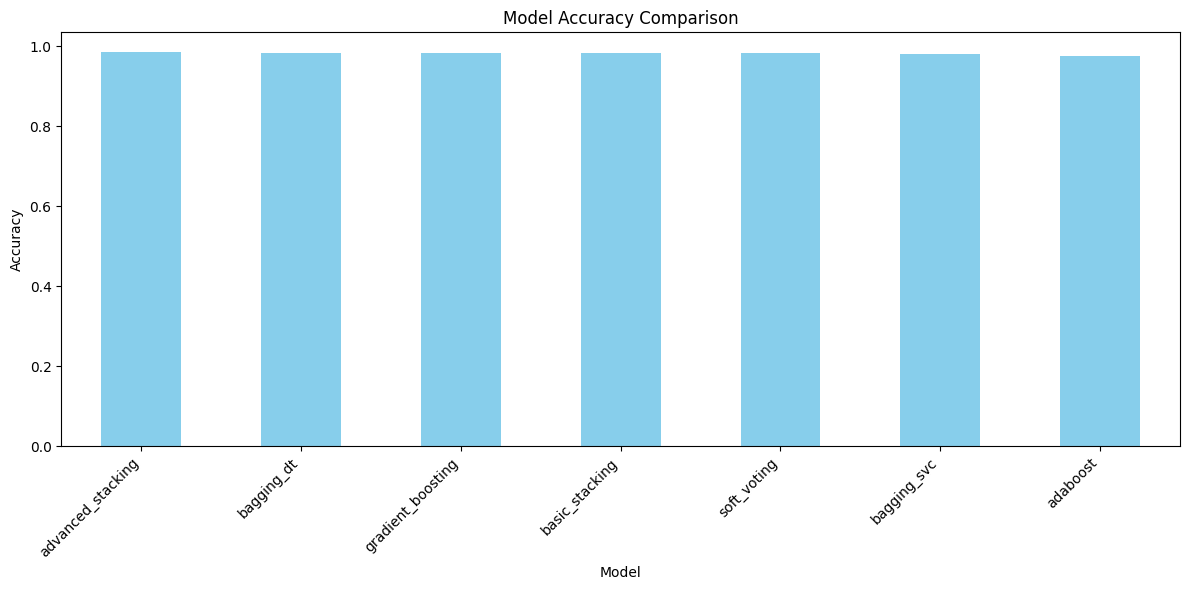

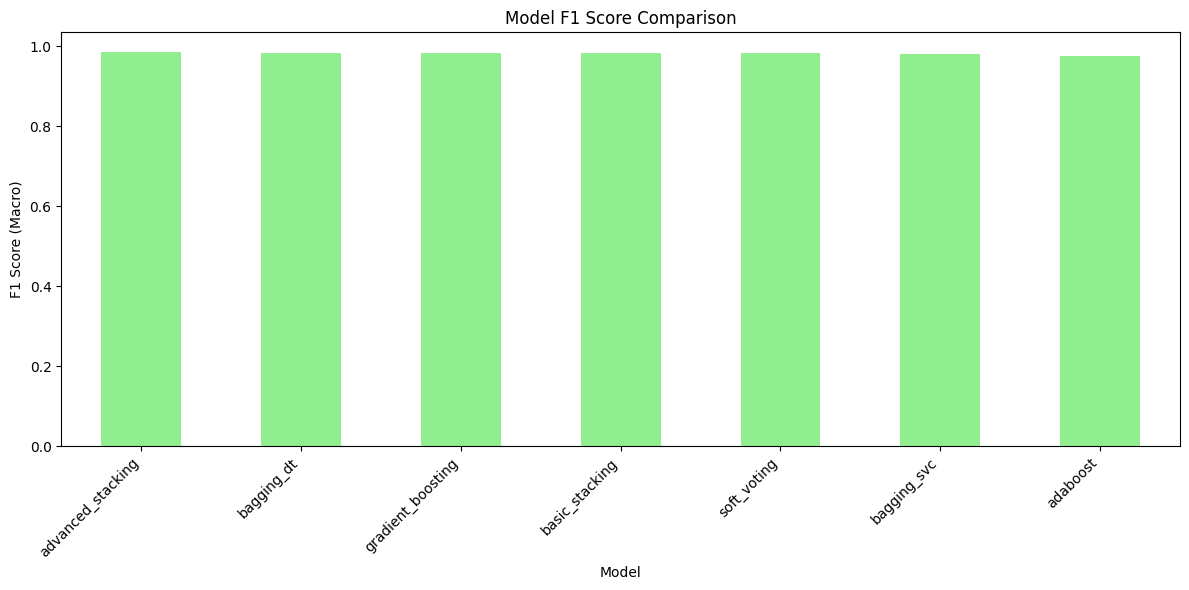


Best performing model: advanced_stacking
Best model performance: accuracy     0.985388
precision    0.985465
recall       0.985343
f1_macro     0.985385
Name: advanced_stacking, dtype: float64


In [20]:
if __name__ == "__main__":
    X, y = valid_data.drop('label',axis=1), valid_data.label
    X_test , y_test = test_data.drop('label',axis = 1) , test_data.label
    
    # Instantiate and run the experiments
    experiment = EnsembleExperiments(X, y , X_test , y_test)
    experiment.run_all_experiments()